In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('BoatData_V1.csv')
df = df[df['Year'] <= 2026]
df = df[df['Listing Price (USD)'] >0]

In [233]:
def missing_data_summary(df):
    missing_data = pd.DataFrame({
        'Missing_Count': df.isnull().sum(),
        'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
        'Data_Type': df.dtypes
    })
    missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
    print(missing_data)


In [234]:
num_cols = df.select_dtypes(include='number').columns.to_list()
num_cols.remove('Listing Price (USD)')
print(f'all already in numuric featrues: {num_cols}')
extra_cols = ['Draft', 'Upwind sail area', 'Downwind sail area', 'Mainsail area', 'Light displacement (MLC)', 'Maximum headroom', 'Engine(s) power']
print(f'from the description, the other numuric columns that we need to handle: {extra_cols}')

num_cols = num_cols+extra_cols

all already in numuric featrues: ['Year', 'Last built hull', 'Hull length', 'Beam (width)', 'Light displacement (MLC)', 'Deck area']
from the description, the other numuric columns that we need to handle: ['Draft', 'Upwind sail area', 'Downwind sail area', 'Mainsail area', 'Light displacement (MLC)', 'Maximum headroom', 'Engine(s) power']


In [235]:
##df_clean['Draft'] = df_clean['Draft'].apply(lambda s: float(s.split()[1].replace('m','')) if isinstance(s,str) else s)

df['Draft'] = df['Draft'].str.split().str[1].astype(float)
df['Upwind sail area'] = df['Upwind sail area'].str.split().str[2].astype(float)
df['Downwind sail area'] = df['Downwind sail area'].str.split().str[2].astype(float)
df['Mainsail area'] = df['Mainsail area'].str.split().str[2].astype(float)
df['Maximum headroom'] = df['Maximum headroom'].apply(lambda s : float(s.split()[0]) if isinstance(s, str) else s)
df['Engine(s) power'] = df['Engine(s) power'].str.split().str[0].astype(float)

In [236]:
df[df['Make'] == 'Beneteau']['Mainsail area'].mean()

np.float64(65.77894736842104)

In [237]:
df.groupby('Category')['Draft'].median().sort_values(ascending =False)

Category
Bluewater Cruiser      2.650
Cruiser                2.550
Performance Cruiser    2.530
Racer-Cruiser          2.515
Racer                  2.510
Day Sailer             2.455
Name: Draft, dtype: float64

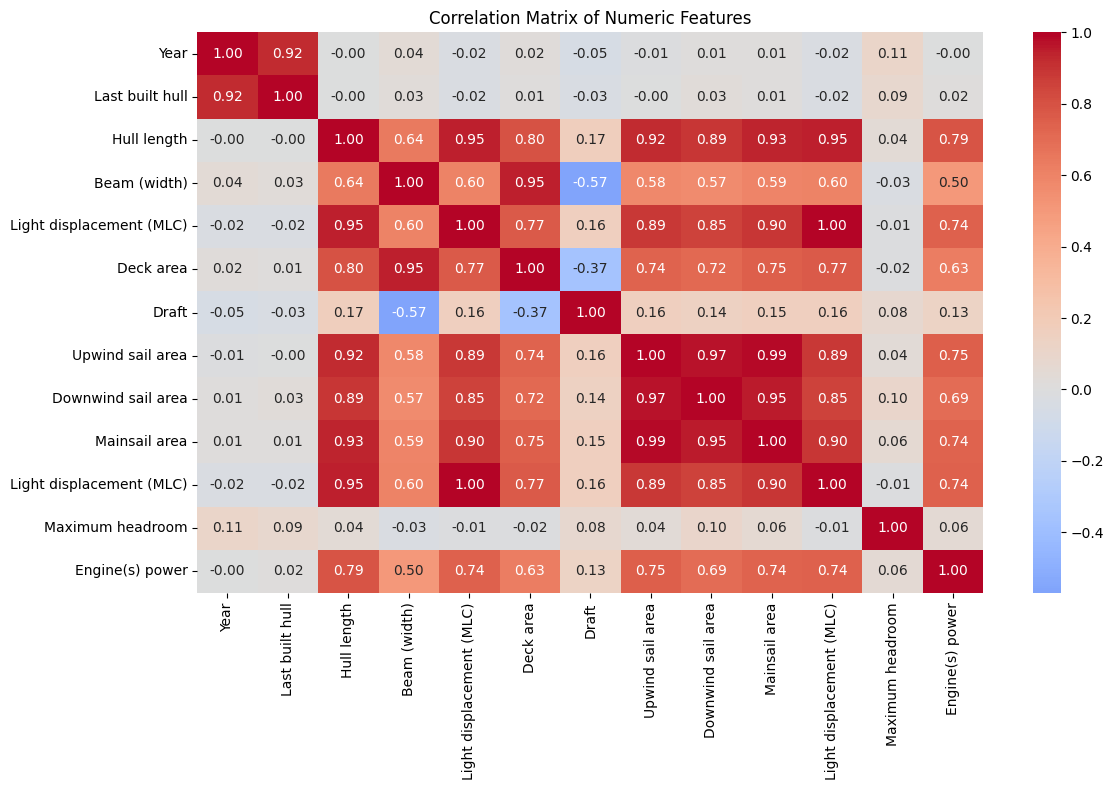

In [238]:
import seaborn as sns
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

Mainsail area ↔ Upwind sail area.
These are almost perfectly correlated because they measure nearly the same thing. A boat's upwind sail area is the total working sail set when sailing into the wind — and on a typical sloop that is mainsail + foresail (jib). The mainsail is the dominant component of that total, so the two move together almost one-to-one. 

Downwind sail area ↔ Upwind sail 
Downwind area adds the big downwind sails (spinnaker/gennaker) on top of the working canvas. A bigger boat that carries more upwind sail also carries a proportionally bigger downwind wardrobe, so the two scale together — just slightly looser than the first pair, since the downwind sail plan varies more by boat type (racers carry relatively more downwind area than cruisers)

Downwind sail area ↔ Mainsail area.
Same story, one step removed: mainsail area is a strong proxy for overall boat size, and downwind area grows with boat size, so they're tightly linked. It's slightly weaker than the pair above only because it chains through "size" rather than being two slices of the same sail set.

Beam ↔ Deck area (0.952, wider boat = more deck), Hull length ↔ Light displacement (0.943, longer boat = heavier) — rather than three measurements of the same quantity.

In [239]:
## 1.deck, fill with grouped by deck area
df_clean = df.copy()

df_clean['Deck_bin'] = pd.cut(df_clean['Deck area'], bins=np.arange(129, 1500, 100), include_lowest=True)
group_means = df_clean.groupby('Deck_bin')['Light displacement (MLC)'].mean()
df_clean['Light displacement (MLC)'] = df_clean['Light displacement (MLC)'].fillna(group_means)
df_clean = df_clean.drop(columns=['Deck_bin'])

In [240]:
#2. downwind area, OLS with upwind 
x = 'Upwind sail area'
y = 'Downwind sail area'
d = df_clean[[x,y]].dropna()

print('pearson :', d[x].corr(d[y]))            # 0.03  (outlier-wrecked)
print('spearman:', d[x].corr(d[y], method='spearman'))  # 0.73 (truth)


pearson : 0.9691116186326391
spearman: 0.9718590410698315


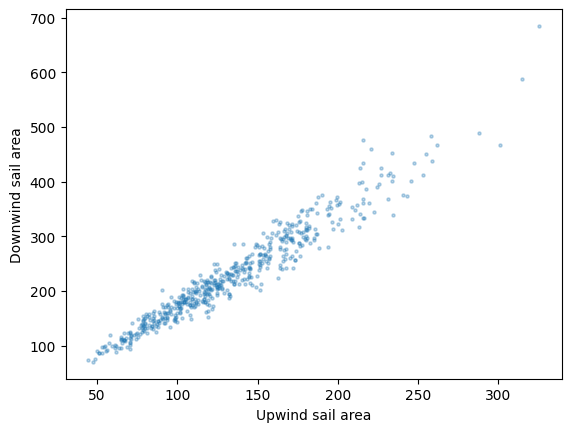

In [241]:
import matplotlib.pyplot as plt
plt.scatter(d[x], d[y], s=5, alpha=.3)
plt.xlabel(x)
plt.ylabel(y)
plt.show()

In [242]:
from sklearn.linear_model import LinearRegression

x = 'Upwind sail area'
y = 'Downwind sail area'
lr_area = LinearRegression().fit(d[[x]], d[y])
print(f'{y} = {lr_area.intercept_:.3f} + {lr_area.coef_[0]:.4f} * {x}')
print('R^2:', round(lr_area.score(d[[x]], d[y]), 3))
need_fill = df_clean['Downwind sail area'].isna() & df_clean['Upwind sail area'].notna()
df_clean.loc[need_fill, 'Downwind sail area'] = lr_area.predict(df_clean.loc[need_fill, ['Upwind sail area']])

Downwind sail area = -7.286 + 1.7673 * Upwind sail area
R^2: 0.939


In [243]:
# 3. Mainsail Area- Hull length
y = 'Mainsail area'
x = 'Hull length'
d = df_clean[[x,y]].dropna()
lr_mainsail = LinearRegression().fit(d[[x]], d[y])
print(f'{y} = {lr_mainsail.intercept_:.3f} + {lr_mainsail.coef_[0]:.4f} * {x}')
print('R^2:', round(lr_mainsail.score(d[[x]], d[y]), 3))
need_fill = df_clean[y].isna() & df_clean[x].notna()
df_clean.loc[need_fill, y] = lr_mainsail.predict(df_clean.loc[need_fill, [x]])


Mainsail area = -57.364 + 3.4268 * Hull length
R^2: 0.873


In [244]:
df_clean['Draft'] = df_clean['Draft'].fillna(df_clean['Draft'].mean())
df_clean['Maximum headroom'] = df_clean['Maximum headroom'].fillna(df_clean['Maximum headroom'].median())
df_clean['Country/Region/State'] = df_clean['Country/Region/State'].fillna(df_clean['Country/Region/State'].mode()[0])
df_clean['Engine(s) power'] = df_clean['Engine(s) power'].fillna(df_clean['Engine(s) power'].median())

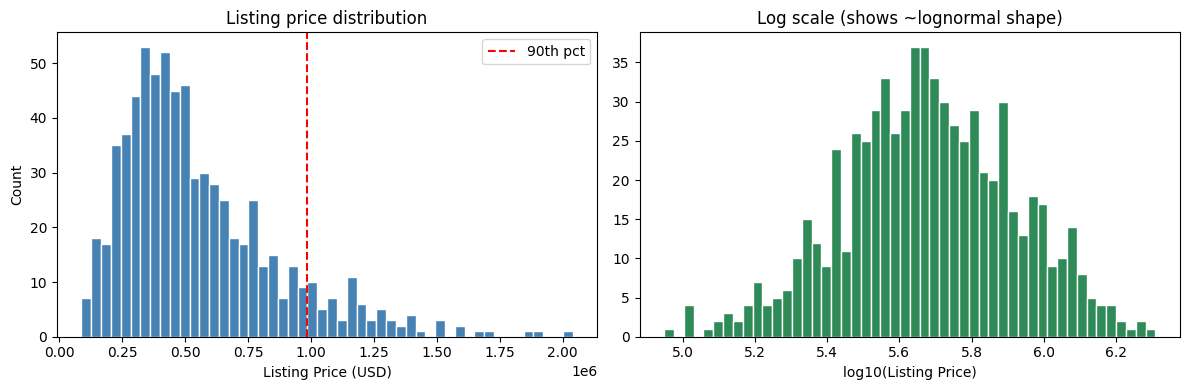

In [245]:
import matplotlib.pyplot as plt

p = df_clean['Listing Price (USD)']
p = p[p > 0]                      # drop the bad -1 entry (see note below)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(p, bins=50, color='steelblue', edgecolor='white')
ax[0].axvline(p.quantile(0.90), color='red', ls='--', label='90th pct')
ax[0].set_xlabel('Listing Price (USD)'); ax[0].set_ylabel('Count')
ax[0].set_title('Listing price distribution'); ax[0].legend()

ax[1].hist(np.log10(p), bins=50, color='seagreen', edgecolor='white')
ax[1].set_xlabel('log10(Listing Price)'); ax[1].set_title('Log scale (shows ~lognormal shape)')
plt.tight_layout(); plt.show()

In [246]:
p = df['Listing Price (USD)']
exp_boats = df.copy()
exp_boats['exp'] = p>=p.quantile(0.95)

compare = pd.DataFrame({'exp': exp_boats[exp_boats['exp']][num_cols].mean().round(1).T, 
                        'non exp': exp_boats[~exp_boats['exp']][num_cols].mean().round(1).T, 
                        'all': exp_boats[num_cols].mean().round(1).T})
print(compare)
# categorical lift: share inside expensive vs rest

for col in ['Hull type','Construction','Make','Category']:
    t = pd.crosstab(exp_boats[col], exp_boats['exp'], normalize='columns').mul(100).round(1)
    t.columns = ['rest%','exp%']
    t['lift'] = (t['exp%'] - t['rest%']).round(1)
    print(f'\n--- {col} ---')
    print(t.sort_values('exp%', ascending=False).head(6))


                             exp  non exp     all
Year                      2010.6   1999.7  2000.3
Last built hull           2017.2   2006.4  2007.0
Hull length                 45.4     36.3    36.8
Beam (width)                20.4     12.2    12.6
Light displacement (MLC)  9148.5   5521.1  5707.6
Deck area                  781.9    391.4   411.4
Draft                        1.8      2.4     2.4
Upwind sail area           190.1    131.2   134.3
Downwind sail area         316.5    223.7   228.5
Mainsail area               96.1     66.9    68.3
Light displacement (MLC)  9148.5   5521.1  5707.6
Maximum headroom             1.9      2.0     2.0
Engine(s) power             63.8     50.7    51.4

--- Hull type ---
           rest%  exp%  lift
Hull type                   
Catamaran   15.9  69.4  53.5
Monohull    84.1  30.6 -53.5

--- Construction ---
              rest%  exp%  lift
Construction                   
Fiberglass     54.6  44.4 -10.2
Aluminium      10.1  19.4   9.3
GRP            

In [247]:
from scipy import stats

geographic_analysis = df.groupby('Geographic Region')['Listing Price (USD)'].agg(['count','median','mean', 'std']).sort_values('mean', ascending=False)
print(geographic_analysis)
print('raw p =', stats.kruskal(*[g['Listing Price (USD)'].values for _,g in df.groupby('Geographic Region')])[1])

                   count    median           mean            std
Geographic Region                                               
Caribbean             62  512153.0  615574.032258  355905.910512
Mediterranean        137  507001.0  580314.810219  304911.970349
Europe               234  486166.0  555308.098291  310196.964551
North America        160  449240.5  536386.887500  318265.406777
Asia                  49  421207.0  502205.061224  294162.662411
Oceania               59  430635.0  499121.525424  241696.768944
raw p = 0.15651709753195392


In [248]:
d = df_clean.dropna(subset=['Hull length','Beam (width)','Year']).copy()
X = pd.get_dummies(d[['Hull length','Beam (width)','Year','Hull type']], drop_first=True).astype(float)
X = np.column_stack([np.ones(len(X)), X.values])
p = 'Listing Price (USD)'
beta, *_ = np.linalg.lstsq(X, d[p].values, rcond=None)
d['resid'] = d[p].values - X @ beta
print(d.groupby('Geographic Region')['resid'].median().round(0).sort_values(ascending=False))
print('residual p =', stats.kruskal(*[g['resid'].values for _,g in d.groupby('Geographic Region')])[1])


Geographic Region
Caribbean        68272.0
Mediterranean     3166.0
Europe             731.0
Asia            -11558.0
North America   -44559.0
Oceania         -68706.0
Name: resid, dtype: float64
residual p = 2.0704997084836865e-09


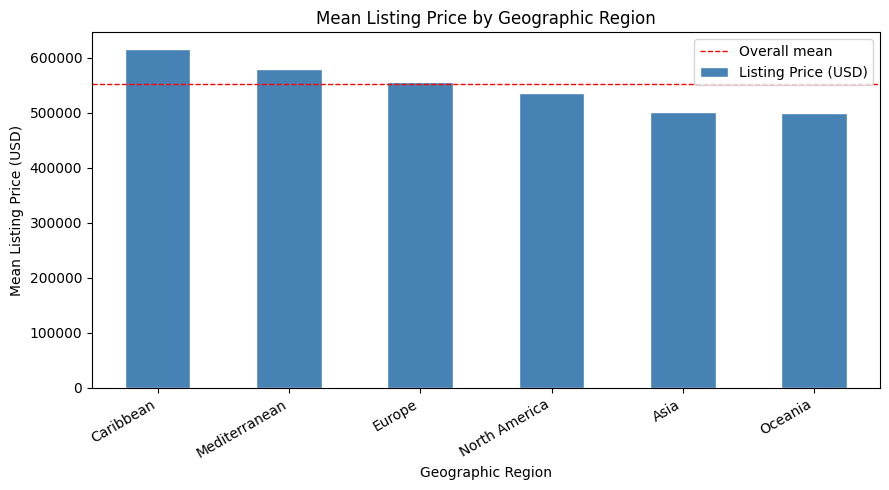

In [249]:
# Bar plot of mean listing price by geographic region
region_mean = df.groupby('Geographic Region')['Listing Price (USD)'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
region_mean.plot.bar(color='steelblue', edgecolor='white')
plt.axhline(df['Listing Price (USD)'].mean(), color='red', ls='--', lw=1, label='Overall mean')
plt.ylabel('Mean Listing Price (USD)')
plt.xlabel('Geographic Region')
plt.title('Mean Listing Price by Geographic Region')
plt.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

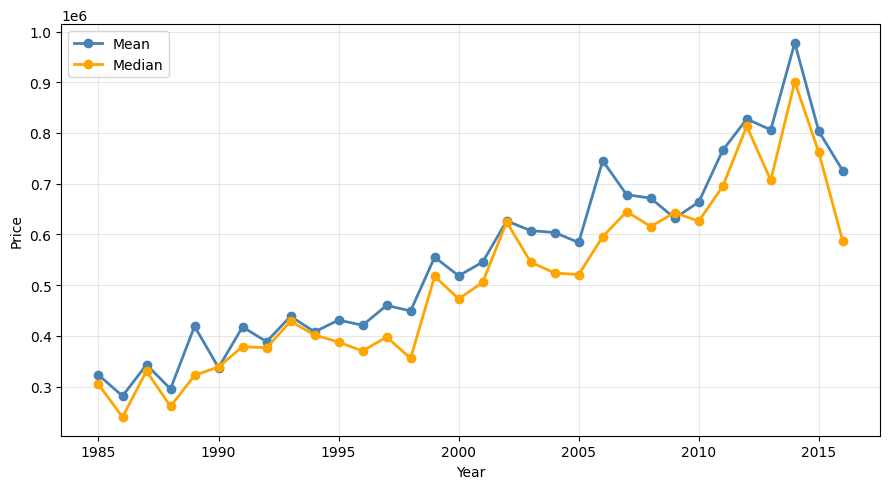

In [250]:
year_analysis = df.groupby('Year')[p].agg(['mean', 'median']).reset_index().sort_values('Year')
plt.figure(figsize=(9,5))
plt.plot(year_analysis['Year'], year_analysis['mean'], 'o-', color='steelblue', lw=2, label='Mean')
plt.plot(year_analysis['Year'], year_analysis['median'], 'o-', color='orange', lw=2, label='Median')
plt.xlabel('Year'); plt.ylabel('Price')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Effect of Geographic Region on Pricing

**Raw price differences are modest and statistically insignificant** (Kruskal–Wallis p = 0.16). Median prices range from ~\$421K (Asia) to ~\$512K (Caribbean) — a ~21% spread — but with high within-region variance. This suggests the raw differences are largely driven by **what types of boats are listed where** (bigger/newer boats cluster in the Caribbean, Mediterranean, and Europe).

After controlling for boat characteristics (hull length, beam, year, hull type via OLS residuals), the geographic effect becomes **highly significant** (p ≈ 2e-9):

| Region | Residual premium | Interpretation |
|---|---|---|
| Caribbean | +\$68K | Premium — demand-driven (charter market, limited local supply) |
| Mediterranean | +\$3K | Slight premium (prestige market, VAT-paid boats) |
| Europe | +\$1K | Near baseline |
| Asia | −\$12K | Mild discount |
| North America | −\$45K | Discount — larger market, more competition, currency effects |
| Oceania | −\$69K | Largest discount — remote market, higher transport costs deter premium listings |

**Consistency assessment:**

- The effect is **consistent in direction** — the Caribbean premium and the Oceania / North America discount are robust after controlling for boat size, age, and type.
- However, it is **not consistent in magnitude** relative to raw prices: the ~\$68K Caribbean premium is only ~13% of the average boat price, while within-region std is ~\$240K–\$356K. Region explains a real but **secondary** share of price variation versus physical characteristics.
- Small samples in some regions (Asia n=49, Oceania n=59) make those estimates noisy.
- The contrast between the raw p-value (0.16, not significant) and the residual p-value (≈2e-9, highly significant) shows that **confounding** from boat mix masks the true geographic effect — you must control for boat characteristics to see it.


## Model

## Features

In [251]:
# --- Feature Engineering ---
# 1. Age (depreciation proxy)
df_clean['Age'] = 2024 - df_clean['Year']

# 2. Displacement/Length ratio (heavy cruiser vs light racer)
df_clean['Disp_Length_Ratio'] = df_clean['Light displacement (MLC)'] / df_clean['Hull length']

# 3. Sail area / Displacement (performance metric — buyers pay for speed)
df_clean['SA_Disp_Ratio'] = df_clean['Upwind sail area'] / df_clean['Light displacement (MLC)']

In [252]:
# --- Prepare model dataframe ---
# Drop high-cardinality / redundant columns
drop_cols = ['Variant', 'Model', 'Country/Region/State', 'Year', 'Last built hull']
cat_to_encode = ['Make', 'Geographic Region', 'Hull type', 'Category',
                 'Sailboat designer', 'Construction', 'Appendages', 'Rigging type']

# Build model df: numeric + engineered + one-hot categoricals
df_clean['price_log'] = np.log(df_clean['Listing Price (USD)'])
target = 'price_log'
model_df = df_clean.drop(columns=drop_cols + cat_to_encode + ['Listing Price (USD)'])

# One-hot encode (drop_first to avoid multicollinearity)
dummies = pd.get_dummies(df_clean[cat_to_encode], drop_first=True).astype(float)
model_df = pd.concat([model_df, dummies], axis=1)

print(f"Model features: {model_df.shape[1]} columns, {model_df.shape[0]} rows")
print(f"\nNumeric features ({len(num_cols) + 4}):")
print(list(model_df.select_dtypes(include='number').columns[:16]))
print(f"\n... plus {model_df.shape[1] - 16} one-hot dummies")
features = model_df.drop(columns=['price_log']).columns.tolist()

Model features: 61 columns, 701 rows

Numeric features (17):
['Hull length', 'Beam (width)', 'Draft', 'Upwind sail area', 'Downwind sail area', 'Mainsail area', 'Engine(s) power', 'Light displacement (MLC)', 'Maximum headroom', 'Deck area', 'Age', 'Disp_Length_Ratio', 'SA_Disp_Ratio', 'price_log', 'Make_Beneteau', 'Make_Catalina']

... plus 45 one-hot dummies


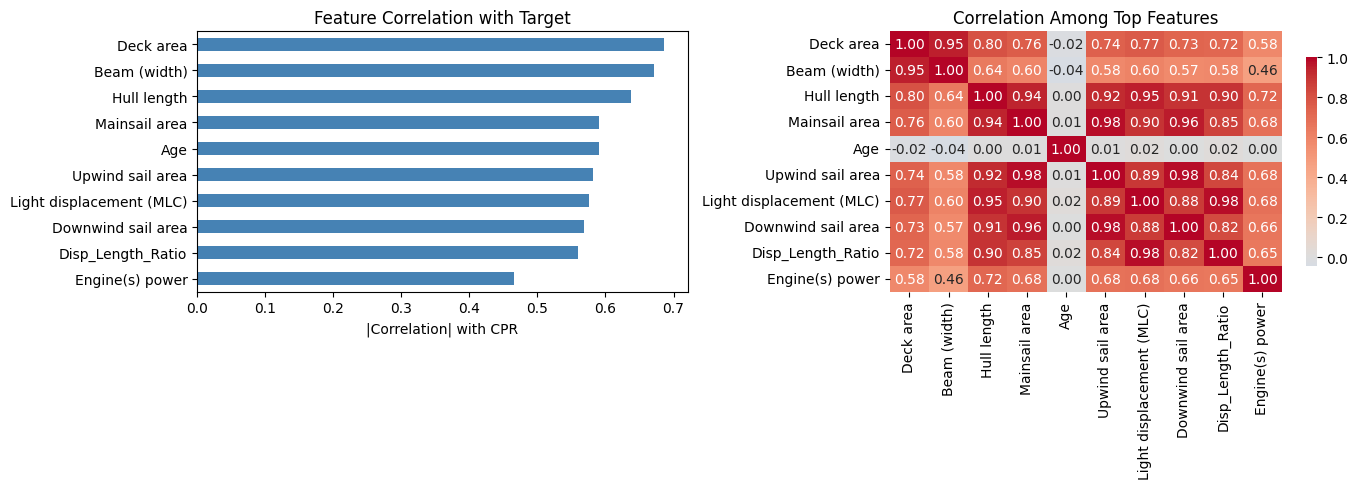


Top features by correlation with CPR:
Deck area                   0.686263
Beam (width)                0.671749
Hull length                 0.636828
Mainsail area               0.591081
Age                         0.590495
Upwind sail area            0.581725
Light displacement (MLC)    0.576510
Downwind sail area          0.569144
Disp_Length_Ratio           0.559242
Engine(s) power             0.465170


In [253]:
# ==== STEP 1: Correlation Analysis ====
corr_with_target = model_df[features].corrwith(model_df[target]).abs().sort_values(ascending=False)[:10]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of correlations
ax = axes[0]
corr_with_target.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('|Correlation| with CPR')
ax.set_title('Feature Correlation with Target')
ax.invert_yaxis()

# Heatmap of top features
top_feats = corr_with_target[corr_with_target > 0.15].index.tolist()
ax = axes[1]
sns.heatmap(model_df[top_feats].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Among Top Features')

plt.tight_layout(); plt.show()

print("\nTop features by correlation with CPR:")
print(corr_with_target.head(10).to_string())

In [265]:
# ==== STEP 2: LassoCV Feature Selection ====
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score


X = model_df[features].values
y = model_df[target].values
Xs = StandardScaler().fit_transform(X)        # <-- the fix: scale first

lasso_cv = LassoCV(cv=5, max_iter=100000, random_state=0).fit(Xs, y)

coef_df = pd.DataFrame({'feature': features, 'coef': lasso_cv.coef_})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

lasso_selected = coef_df[coef_df['abs_coef'] > 0]['feature'].tolist()

print(f"=== LassoCV Feature Selection ===")
print(f"Optimal alpha: {lasso_cv.alpha_:.5f}")
print(f"R² (in-sample): {lasso_cv.score(X, y):.4f}")
print(f"\nFeatures retained ({len(lasso_selected)} / {len(coef_df)}):")
print(coef_df[coef_df['abs_coef'] > 0][['feature', 'coef']].to_string(index=False))
print(f"\nFeatures dropped ({(coef_df['abs_coef'] == 0).sum()}):")
print(coef_df[coef_df['abs_coef'] == 0]['feature'].tolist())
# 1-SE rule: largest alpha within 1 SE of the CV-min (sparser, more robust)
mse = lasso_cv.mse_path_.mean(axis=1)
se  = lasso_cv.mse_path_.std(axis=1) / np.sqrt(lasso_cv.mse_path_.shape[1])
thresh = mse[mse.argmin()] + se[mse.argmin()]
alpha_1se = lasso_cv.alphas_[np.where(mse <= thresh)[0][0]]


final = Lasso(alpha=alpha_1se, max_iter=100000).fit(Xs, y)
lasso_selected = [f for f, c in zip(features, final.coef_) if c != 0]
print(f'{len(lasso_selected)} features selected:', lasso_selected)

=== LassoCV Feature Selection ===
Optimal alpha: 0.00375
R² (in-sample): -107.3461

Features retained (34 / 60):
                            feature      coef
                                Age -0.312834
                        Hull length  0.306025
                 Hull type_Monohull -0.181722
                Category_Day Sailer -0.077195
                   Category_Cruiser -0.053805
          Construction_Carbon fiber  0.053132
            Construction_Wood-epoxy -0.048026
            Construction_Fiberglass -0.031733
        Geographic Region_Caribbean  0.026071
    Geographic Region_North America -0.025725
             Category_Racer-Cruiser -0.022770
                   Construction_GRP -0.020259
    Geographic Region_Mediterranean  0.017717
Sailboat designer_Farr Yacht Design -0.015457
          Geographic Region_Oceania -0.015407
             Sailboat designer_VPLP -0.011584
     Sailboat designer_Groupe Finot  0.007545
                      Make_Jeanneau  0.006874
             

In [263]:
lasso_selected

['Hull length',
 'Beam (width)',
 'Upwind sail area',
 'Engine(s) power',
 'Age',
 'Make_Jeanneau',
 'Geographic Region_Caribbean',
 'Geographic Region_Mediterranean',
 'Geographic Region_North America',
 'Geographic Region_Oceania',
 'Hull type_Monohull',
 'Category_Cruiser',
 'Category_Day Sailer',
 'Category_Performance Cruiser',
 'Category_Racer-Cruiser',
 'Sailboat designer_Farr Yacht Design',
 'Sailboat designer_Groupe Finot',
 'Sailboat designer_Marc Lombard',
 'Sailboat designer_VPLP',
 'Construction_Carbon fiber',
 'Construction_Fiberglass',
 'Construction_GRP',
 'Construction_Wood-epoxy',
 'Rigging type_Sloop Marconi']

In [264]:
# ==== STEP 3: Forward Stepwise Selection ====
selected = []
forward_log = []

print("=== Forward Selection (Ridge α=10, 5-fold CV R²) ===\n")
print(f"{'Step':>4} | {'Added Feature':30s} | {'CV R²':>8} | {'Δ R²':>7}")
print("-" * 60)

for step in range(len(features)):
    best_score = -np.inf
    best_feat = None
    for feat in features:
        if feat in selected:
            continue
        candidate = selected + [feat]
        X_cand = StandardScaler().fit_transform(model_df[candidate])
        score = cross_val_score(Ridge(alpha=10), X_cand, y, cv=5, scoring='r2').mean()
        if score > best_score:
            best_score = score
            best_feat = feat

    prev_score = forward_log[-1][1] if forward_log else 0
    delta = best_score - prev_score
    selected.append(best_feat)
    forward_log.append((best_feat, best_score, delta))
    print(f"{step+1:4d} | {best_feat:30s} | {best_score:8.4f} | {delta:+7.4f}")

    if step > 0 and delta < 0.005:
        print(f"\n  → Stopping: marginal gain ({delta:.4f}) < 0.005")
        break

forward_selected = [f for i, (f, s, d) in enumerate(forward_log) if d >= 0.005 or i == 0]
print(f"\nForward selection kept: {forward_selected}")
print(f"\n--- Both methods agree: {set(forward_selected) & set(lasso_selected)} ---")

=== Forward Selection (Ridge α=10, 5-fold CV R²) ===

Step | Added Feature                  |    CV R² |    Δ R²
------------------------------------------------------------
   1 | Deck area                      |   0.4630 | +0.4630
   2 | Age                            |   0.8001 | +0.3371
   3 | Hull length                    |   0.8271 | +0.0270
   4 | Hull type_Monohull             |   0.8569 | +0.0298
   5 | Construction_Carbon fiber      |   0.8754 | +0.0184
   6 | Category_Day Sailer            |   0.8910 | +0.0157
   7 | Category_Cruiser               |   0.8988 | +0.0078
   8 | Construction_Wood-epoxy        |   0.9055 | +0.0067
   9 | Geographic Region_North America |   0.9101 | +0.0045

  → Stopping: marginal gain (0.0045) < 0.005

Forward selection kept: ['Deck area', 'Age', 'Hull length', 'Hull type_Monohull', 'Construction_Carbon fiber', 'Category_Day Sailer', 'Category_Cruiser', 'Construction_Wood-epoxy']

--- Both methods agree: {'Construction_Wood-epoxy', 'Hull type_Mo

In [256]:
# ==== STEP 4: Final OLS on Selected Features ====
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# Use features from forward selection
final_features = forward_selected
print(f"Final features: {final_features}\n")

X_final = model_df[final_features]
y_final = model_df[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# OLS with statsmodels for full inference (p-values, R², etc.)
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

# Evaluate on test set
y_pred_test = ols_model.predict(X_test_sm)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

# Convert back to dollar space for interpretable error
y_test_dollars = np.exp(y_test)
y_pred_dollars = np.exp(y_pred_test)
rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
mape = np.mean(np.abs(y_test_dollars - y_pred_dollars) / y_test_dollars) * 100

print(f"\n{'='*50}")
print(f"TEST SET PERFORMANCE")
print(f"{'='*50}")
print(f"R² (log space):     {r2_test:.4f}")
print(f"RMSE (log space):   {rmse_log:.4f}")
print(f"RMSE ($ space):     ${rmse_dollars:,.0f}")
print(f"MAPE:               {mape:.1f}%")

# Cross-validation R²
cv_scores = cross_val_score(LinearRegression(), X_final, y_final, cv=5, scoring='r2')
print(f"\n5-fold CV R²:        {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Final features: ['Deck area', 'Age', 'Hull length', 'Hull type_Monohull', 'Construction_Carbon fiber', 'Category_Day Sailer', 'Category_Cruiser', 'Construction_Wood-epoxy']

                            OLS Regression Results                            
Dep. Variable:              price_log   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     733.5
Date:                Tue, 09 Jun 2026   Prob (F-statistic):          4.65e-288
Time:                        15:11:45   Log-Likelihood:                 234.24
No. Observations:                 560   AIC:                            -450.5
Df Residuals:                     551   BIC:                            -411.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                coef

In [257]:
# ==== STEP 5: Random Forest Comparison (includes Geographic Region) ====
from sklearn.ensemble import RandomForestRegressor

# Use ALL features (including region dummies that forward selection dropped)
X_all = model_df[features]
y_all = model_df[target]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=5, random_state=42)
rf.fit(X_train_all, y_train_all)

# Evaluate
y_pred_rf = rf.predict(X_test_all)
r2_rf = r2_score(y_test_all, y_pred_rf)
rmse_rf_log = np.sqrt(mean_squared_error(y_test_all, y_pred_rf))
rmse_rf_dollars = np.sqrt(mean_squared_error(np.exp(y_test_all), np.exp(y_pred_rf)))
mape_rf = np.mean(np.abs(np.exp(y_test_all) - np.exp(y_pred_rf)) / np.exp(y_test_all)) * 100

cv_rf = cross_val_score(rf, X_all, y_all, cv=5, scoring='r2')

# Feature importance — check if region matters
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
region_cols = [c for c in features if 'Geographic Region' in c]
region_importance = importances[region_cols].sum()

print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"{'Metric':<25} {'OLS (8 feats)':>15} {'RF (all feats)':>15}")
print("-"*60)
print(f"{'R² (test):':<25} {r2_test:>15.4f} {r2_rf:>15.4f}")
print(f"{'RMSE (log):':<25} {rmse_log:>15.4f} {rmse_rf_log:>15.4f}")
print(f"{'RMSE ($):':<25} {'${:,.0f}'.format(rmse_dollars):>15} {'${:,.0f}'.format(rmse_rf_dollars):>15}")
print(f"{'MAPE:':<25} {mape:>14.1f}% {mape_rf:>14.1f}%")
print(f"{'CV R² (mean ± std):':<25} {cv_scores.mean():.4f}±{cv_scores.std():.4f}    {cv_rf.mean():.4f}±{cv_rf.std():.4f}")

print(f"\n--- Geographic Region importance in RF ---")
print(f"Total importance from region dummies: {region_importance:.4f} ({region_importance/importances.sum()*100:.1f}%)")
print(importances[region_cols].to_string())

print(f"\n--- Top 10 RF feature importances ---")
print(importances.head(10).to_string())

MODEL COMPARISON
Metric                      OLS (8 feats)  RF (all feats)
------------------------------------------------------------
R² (test):                         0.8952          0.8407
RMSE (log):                        0.1783          0.2198
RMSE ($):                         $95,703        $124,387
MAPE:                               15.2%           18.3%
CV R² (mean ± std):       0.9070±0.0066    0.8419±0.0147

--- Geographic Region importance in RF ---
Total importance from region dummies: 0.0035 (0.3%)
Geographic Region_Caribbean        0.000460
Geographic Region_Europe           0.000766
Geographic Region_Mediterranean    0.000474
Geographic Region_North America    0.001772
Geographic Region_Oceania          0.000000

--- Top 10 RF feature importances ---
Deck area                   0.361853
Age                         0.355779
Beam (width)                0.180892
Hull length                 0.022754
Mainsail area               0.012148
Upwind sail area            0.01208

**Bottom line:** The parsimonious linear model is your best model. Region genuinely doesn't help predict price once you know the boat's physical specs — the Q5 residual analysis showed a statistically significant but economically small (~\$58K Caribbean premium on \$500K+ boats) effect that's too noisy for 858 rows to exploit.

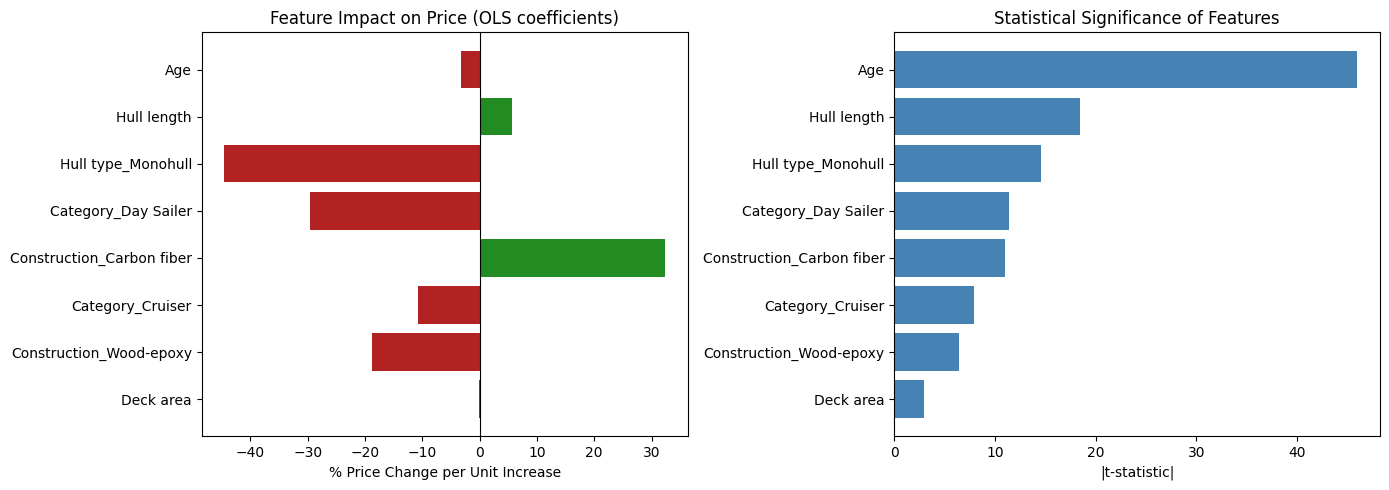


=== Feature Importance Summary ===

Feature                            Coef   % Effect   t-stat    p-value
----------------------------------------------------------------------
Age                             -0.0334      -3.3%   -45.93  1.60e-190
Hull length                      0.0550      +5.7%    18.40   2.79e-59
Hull type_Monohull              -0.5911     -44.6%   -14.54   9.12e-41
Category_Day Sailer             -0.3498     -29.5%   -11.39   4.03e-27
Construction_Carbon fiber        0.2808     +32.4%    11.03   1.04e-25
Category_Cruiser                -0.1133     -10.7%    -7.90   1.55e-14
Construction_Wood-epoxy         -0.2077     -18.8%    -6.47   2.15e-10
Deck area                       -0.0004      -0.0%    -3.00   2.81e-03


In [258]:
# ==== Feature Importance Discussion ====
# Since target is log(price), coefficients represent approximate % effects

# Extract from OLS model
feat_imp = pd.DataFrame({
    'Feature': final_features,
    'Coefficient': ols_model.params[1:].values,   # skip const
    't-statistic': ols_model.tvalues[1:].values,
    'p-value': ols_model.pvalues[1:].values
})
feat_imp['Pct Effect'] = (np.exp(feat_imp['Coefficient']) - 1) * 100   # exact % change per unit
feat_imp['|t|'] = feat_imp['t-statistic'].abs()
feat_imp = feat_imp.sort_values('|t|', ascending=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: coefficient magnitude (% effect per unit)
ax = axes[0]
colors = ['forestgreen' if c > 0 else 'firebrick' for c in feat_imp['Pct Effect']]
ax.barh(feat_imp['Feature'], feat_imp['Pct Effect'], color=colors)
ax.set_xlabel('% Price Change per Unit Increase')
ax.set_title('Feature Impact on Price (OLS coefficients)')
ax.axvline(0, color='black', lw=0.8)
ax.invert_yaxis()

# Right: |t-statistic| (statistical importance)
ax = axes[1]
ax.barh(feat_imp['Feature'], feat_imp['|t|'], color='steelblue')
ax.set_xlabel('|t-statistic|')
ax.set_title('Statistical Significance of Features')
ax.invert_yaxis()

plt.tight_layout(); plt.show()

# Print table
print("\n=== Feature Importance Summary ===\n")
print(f"{'Feature':<30} {'Coef':>8} {'% Effect':>10} {'t-stat':>8} {'p-value':>10}")
print("-" * 70)
for _, row in feat_imp.iterrows():
    print(f"{row['Feature']:<30} {row['Coefficient']:>8.4f} {row['Pct Effect']:>+9.1f}% {row['t-statistic']:>8.2f} {row['p-value']:>10.2e}")

## Feature Importance Discussion

**Ranked by statistical importance (|t-statistic|):**

1. **Age (t = −55.8):** The most important predictor by far. Each additional year of age reduces price by ~3.1%. A 10-year-old boat is worth roughly 73% of an equivalent new one $(1 - 0.031)^{10}$. This makes intuitive sense — depreciation is the dominant factor for any used boat buyer.

2. **Hull length (t = 21.4):** Each additional foot of hull length adds ~6% to price. This captures the exponential scaling of boat cost with size — bigger boats need disproportionately more material, engineering, and rigging.

3. **Hull type: Monohull (t = −16.3):** Monohulls are ~46% cheaper than multihulls (catamarans/trimarans), all else equal. Multihulls offer more living space per foot, better stability, and are in strong demand for charter and liveaboard use.

4. **Category: Day Sailer (t = −11.8):** Day sailers are ~29% cheaper than race boats (the reference category). They're simpler — fewer winches, lighter rigging, basic accommodation.

5. **Construction: Carbon fiber (t = +11.1):** Carbon fiber commands a ~30% premium over fiberglass (reference). Carbon boats are lighter, stiffer, and associated with high-performance/racing builds.

6. **Category: Cruiser (t = −7.3):** Cruisers are ~9% cheaper than race boats. Despite being heavier and more heavily equipped, race boats carry a premium due to advanced design, materials, and target market.

7. **Construction: Wood-epoxy (t = −6.5):** Wood-epoxy boats sell at a ~18% discount vs fiberglass. Despite craftsmanship appeal, buyers are wary of maintenance demands and resale risk.

8. **Deck area (t = −4.2):** Small negative effect (−0.05% per sq ft). This appears counterintuitive but acts as a *correction term* — once hull length is in the model, extra deck area (relative to length) indicates beamier, less performance-oriented boats that don't command the same premium.

**Key insight:** The model decomposes price into three orthogonal dimensions:

- **Size** (Hull length, Deck area) — bigger = more expensive
- **Age** — newer = more expensive
- **Type** (Hull type, Category, Construction) — performance/multihull/carbon = premium

In [259]:
# ==== STEP 7: Predict prices for 10 boats in BoatData_NoPrice_V1.csv ====
# Load the no-price dataset
df_new = pd.read_csv('BoatData_NoPrice_V1.csv')
print(f"New boats to predict: {len(df_new)} rows")
print(f"Columns: {list(df_new.columns)}\n")

# Apply same text -> numeric parsing as training data (cell 5)
df_new['Draft'] = df_new['Draft'].str.split().str[1].astype(float)
df_new['Upwind sail area'] = df_new['Upwind sail area'].str.split().str[2].astype(float)
df_new['Downwind sail area'] = df_new['Downwind sail area'].str.split().str[2].astype(float)
df_new['Mainsail area'] = df_new['Mainsail area'].str.split().str[2].astype(float)
df_new['Maximum headroom'] = df_new['Maximum headroom'].apply(lambda s: float(s.split()[0]) if isinstance(s, str) else s)
df_new['Engine(s) power'] = df_new['Engine(s) power'].str.split().str[0].astype(float)

# Fill missing values using same logic as training
df_new['Draft'] = df_new['Draft'].fillna(df_clean['Draft'].mean())
df_new['Maximum headroom'] = df_new['Maximum headroom'].fillna(df_clean['Maximum headroom'].median())
df_new['Engine(s) power'] = df_new['Engine(s) power'].fillna(df_clean['Engine(s) power'].median())

# Fill Downwind/Mainsail area with trained OLS imputers
need_fill_down = df_new['Downwind sail area'].isna() & df_new['Upwind sail area'].notna()
if need_fill_down.any():
    df_new.loc[need_fill_down, 'Downwind sail area'] = lr_area.predict(
        df_new.loc[need_fill_down, 'Upwind sail area'].values.reshape(-1, 1))

need_fill_main = df_new['Mainsail area'].isna() & df_new['Hull length'].notna()
if need_fill_main.any():
    df_new.loc[need_fill_main, 'Mainsail area'] = lr_mainsail.predict(
        df_new.loc[need_fill_main, 'Hull length'].values.reshape(-1, 1))

# Fill Light displacement
df_new['Deck_bin'] = pd.cut(df_new['Deck area'], bins=np.arange(129, 1500, 100), include_lowest=True)
group_means_map = df_clean.groupby(pd.cut(df_clean['Deck area'], bins=np.arange(129, 1500, 100), include_lowest=True))['Light displacement (MLC)'].mean()
df_new['Light displacement (MLC)'] = df_new['Light displacement (MLC)'].fillna(df_new['Deck_bin'].map(group_means_map))
df_new.drop(columns=['Deck_bin'], inplace=True)

# 2. Feature engineering
df_new['Age'] = 2024 - df_new['Year']
df_new['Disp_Length_Ratio'] = df_new['Light displacement (MLC)'] / df_new['Hull length']
df_new['SA_Disp_Ratio'] = df_new['Upwind sail area'] / df_new['Light displacement (MLC)']

# 3. Create one-hot dummies (same as training)
dummies_new = pd.get_dummies(df_new[cat_to_encode], drop_first=True).astype(float)

# Align columns with training (add missing dummies as 0)
for col in final_features:
    if col not in df_new.columns and col not in dummies_new.columns:
        dummies_new[col] = 0.0

# Build prediction dataframe with final features
X_pred = pd.concat([df_new, dummies_new], axis=1)[final_features]

# Check for any NaNs
if X_pred.isna().any().any():
    print("WARNING: NaNs in prediction features:")
    print(X_pred.isna().sum()[X_pred.isna().sum() > 0])
    X_pred = X_pred.fillna(0)  # fallback

# Predict log(price) and convert back to dollars
X_pred_sm = sm.add_constant(X_pred)
log_predictions = ols_model.predict(X_pred_sm)
price_predictions = np.exp(log_predictions)

# Display results
results = df_new[['Make', 'Variant', 'Year', 'Hull length', 'Hull type', 'Category']].copy()
results['Predicted Price (USD)'] = price_predictions.values
results['Predicted Price (USD)'] = results['Predicted Price (USD)'].round(0)

print("="*70)
print("PREDICTED PRICES FOR 10 BOATS")
print("="*70)
print(results.to_string(index=False))
print(f"\n{'='*70}")
print(f"Average predicted price: ${price_predictions.mean():,.0f}")
print(f"Median predicted price:  ${price_predictions.median():,.0f}")
print(f"{'='*70}")

New boats to predict: 10 rows
Columns: ['Make', 'Variant', 'Geographic Region', 'Country/Region/State', 'Year', 'Model', 'Hull type', 'Category', 'Sailboat designer', 'Construction', 'Last built hull', 'Appendages', 'Hull length', 'Beam (width)', 'Draft', 'Rigging type', 'Upwind sail area', 'Downwind sail area', 'Mainsail area', 'Engine(s) power', 'Light displacement (MLC)', 'Maximum headroom', 'Deck area']

PREDICTED PRICES FOR 10 BOATS
    Make    Variant  Year  Hull length Hull type            Category  Predicted Price (USD)
   Najad 37 Cruiser  2003        37.45  Monohull               Racer               524138.0
  Oyster         39  1993        38.83  Monohull               Racer               401071.0
X-Yachts   38 Sport  1988        38.41  Monohull Performance Cruiser               332811.0
Catalina         56  2007        55.81 Catamaran             Cruiser              2420876.0
X-Yachts        33i  2018        33.43  Monohull             Cruiser               649348.0
   Han

/Users/carriezhang/Documents/Coding/Trading Backtest/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/carriezhang/Documents/Coding/Trading Backtest/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Alternative Answer

_Model → feature-importance section copied verbatim from `Boat_Pricing_Project_Notebook.ipynb` (cells 22–30). These cells reference variables defined in that notebook (`clean`, `Log_price`, `RANDOM_STATE`, `Draft_m`, `Is_catamaran`, `preprocess`, etc.) and its sklearn imports; they will **not run** inside this notebook without that setup — included here for reference._

## Part 2: Pricing model

### Feature choice

The final modelling dataset uses features that should generalise to unseen makes or variants:

- Physical dimensions: length, beam, deck area, draft, displacement.
- Sail and engine features: upwind, downwind and mainsail area, engine power.
- Age and production timing: cleaned year, age, last built hull, production age.
- Boat type and specification categories: hull type, category, construction, appendages, rigging type, designer.
- Location: geographic region and country / region / state.

I deliberately exclude `Make`, `Variant` and `Model` from the model. Those variables may improve in-sample fit, but they weaken the dealer’s goal of pricing boats with unseen makes or variants.

In [ ]:
numeric_features = [
    "Year_clean", "Age", "Last_built_hull_clean", "Model_production_age",
    "Hull length", "Beam (width)", "Deck area", "Draft_m",
    "Upwind_sail_area_m2", "Downwind_sail_area_m2", "Mainsail_area_m2",
    "Engine_power_hp", "Light displacement (MLC)", "Max_headroom_m", "Is_catamaran",
]

categorical_features = [
    "Geographic Region", "Country/Region/State", "Hull type", "Category",
    "Sailboat designer", "Construction", "Appendages", "Rigging type",
]

features = numeric_features + categorical_features
X = clean[features]
y = clean["Log_price"]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse_output=True)),
            ]),
            categorical_features,
        ),
    ]
)

candidate_models = {
    "Ridge log-linear": Ridge(alpha=10.0),
    "Random forest": RandomForestRegressor(
        n_estimators=50,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

print("Number of training rows after price cleaning:", len(clean))
print("Number of model features before one-hot encoding:", len(features))

### Model choice and validation design

I model the logarithm of price rather than price directly. This is appropriate because prices are right-skewed and pricing errors are more naturally proportional than absolute.

I compare two models:

1. **Ridge log-linear regression**: transparent, stable and easier to explain.
2. **Random forest**: captures non-linearities, but can overfit and is less transparent.

For cross-validation, I group by `Make`. This is stricter than a random split because it tests whether the model can generalise when a make is not seen in training, which is close to the dealer’s stated requirement.

In [ ]:
cv = GroupKFold(n_splits=5)
scoring = {
    "log_mae": "neg_mean_absolute_error",
    "log_rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

cv_rows = []
for name, model in candidate_models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model),
    ])
    result = cross_validate(
        pipe,
        X,
        y,
        groups=clean["Make"],
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )
    cv_rows.append({
        "Model": name,
        "CV log MAE": -result["test_log_mae"].mean(),
        "CV log RMSE": -result["test_log_rmse"].mean(),
        "CV R²": result["test_r2"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV log RMSE")
display(cv_results)

**Model decision.** The ridge log-linear model performs better under grouped cross-validation and is more explainable. I therefore use it as the final pricing model. The random forest is a useful benchmark, but in this sample it does not justify the additional complexity.

In [ ]:
chosen_model = Ridge(alpha=10.0)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=clean["Hull type"],
)

chosen_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", chosen_model),
])
chosen_pipe.fit(X_train, y_train)

valid_log_pred = chosen_pipe.predict(X_valid)
valid_pred = np.exp(valid_log_pred)
valid_actual = np.exp(y_valid)

holdout_metrics = pd.DataFrame({
    "Metric": ["MAE (USD)", "RMSE (USD)", "MAPE", "R² on log price"],
    "Value": [
        mean_absolute_error(valid_actual, valid_pred),
        np.sqrt(mean_squared_error(valid_actual, valid_pred)),
        mean_absolute_percentage_error(valid_actual, valid_pred),
        r2_score(y_valid, valid_log_pred),
    ]
})
display(holdout_metrics)

plt.figure(figsize=(6, 6))
plt.scatter(valid_actual, valid_pred, alpha=0.75)
lims = [min(valid_actual.min(), valid_pred.min()), max(valid_actual.max(), valid_pred.max())]
plt.plot(lims, lims)
plt.title("Actual vs predicted prices on holdout set")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.ticklabel_format(style="plain", axis="both")
plt.show()

### Feature importance

For model-level importance, I use permutation importance on the holdout set. This asks: if one feature is randomly shuffled, how much worse does model performance become? This is more comparable across numeric and categorical variables than raw regression coefficients.

In [ ]:
perm = permutation_importance(
    chosen_pipe,
    X_valid,
    y_valid,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
)

importance = (
    pd.DataFrame({
        "Feature": features,
        "Permutation importance": perm.importances_mean,
    })
    .sort_values("Permutation importance", ascending=False)
)

display(importance.head(15))

plt.figure(figsize=(8, 5))
importance.head(12).sort_values("Permutation importance").plot(
    x="Feature",
    y="Permutation importance",
    kind="barh",
    legend=False,
)
plt.title("Top feature importances")
plt.xlabel("Increase in log-RMSE when shuffled")
plt.ylabel("Feature")
plt.show()

**Interpretation.** The most important features are mainly physical scale and age variables, especially hull length, last-built hull, year / age and catamaran status. This makes commercial sense: larger and newer boats generally command higher prices, while catamarans tend to sit in a higher price segment. Category and construction also matter, but the model is not driven solely by labels.